# Uber Fare Prediction using Spatial-Temporal Modeling and Cross-Dataset Validation

In this notebook, I build an end-to-end fare prediction project with two main goals:

1. Predict ride fares with a transparent modeling pipeline.
2. Understand how spatial and temporal patterns shape prices.

I use a Kaggle Uber fare dataset for feature engineering and modeling, and then validate whether the patterns I learn also appear in a separate real-world NYC Yellow Taxi dataset.

## 1. Introduction

**Central question:** Which factors explain and predict ride fare in a spatial-temporal context?

In this project, I focus on three connected objectives:

- **Prediction:** estimate fare amounts with baseline and nonlinear models.
- **Interpretation:** explain which spatial and temporal signals matter most.
- **Validation:** compare the learned patterns against a second dataset without merging the sources.

Throughout the notebook, I prioritize clear reasoning, honest assumptions, and business-oriented interpretation over unnecessary complexity.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)

RANDOM_STATE = 42

In [2]:
DATA_DIR = Path("DATA")

def find_first(pattern: str) -> Path:
    matches = sorted(DATA_DIR.glob(pattern))
    if not matches:
        raise FileNotFoundError(f"No file found in {DATA_DIR} matching: {pattern}")
    return matches[0]


def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    )

    return 2 * 6371 * np.arcsin(np.sqrt(a)) 


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def schema_overview(df: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "missing_values": df.isna().sum(),
    })

## 2. Data Loading

In this step, I load both datasets from the local DATA/ folder using relative paths only.

- **Kaggle Uber fare dataset:** training and modeling source.
- **NYC Yellow Taxi parquet dataset:** validation-only source for pattern comparison.

To keep memory usage under control, I load only the necessary columns from the NYC parquet file for descriptive analysis.

In [3]:
uber_path = find_first("uber*.csv")
nyc_path = find_first("yellow_tripdata*.parquet")

uber_columns = [
    "fare_amount",
    "pickup_datetime",
    "pickup_longitude",
    "pickup_latitude",
    "dropoff_longitude",
    "dropoff_latitude",
    "passenger_count",
]

nyc_columns = [
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "passenger_count",
    "trip_distance",
    "fare_amount",
    "PULocationID",
    "DOLocationID",
    "total_amount",
]

uber_raw = pd.read_csv(uber_path, usecols=uber_columns)
nyc_raw = pd.read_parquet(nyc_path, columns=nyc_columns)

print(f"Kaggle dataset shape: {uber_raw.shape}")
print(f"NYC validation dataset shape: {nyc_raw.shape}")

Kaggle dataset shape: (200000, 7)
NYC validation dataset shape: (3724889, 8)


## 3. Data Overview

Before cleaning, I briefly inspect the datasets to confirm their structure, identify obvious quality issues, and understand the scale of the available information.

This step helps verify whether the variables are suitable for spatial-temporal analysis before any preprocessing decisions are applied.

In [4]:
display(uber_raw.head())

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [5]:
print("Missing values (Kaggle):")
print(uber_raw.isna().sum())

Missing values (Kaggle):
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64


## 4. Data Cleaning

The Kaggle dataset is my main modeling source, so I make sure every cleaning decision is explicit and well justified.

In this step, I:

- Remove missing values.
- Convert pickup timestamps to timezone-aware datetimes and align them to New York local time for temporal analysis.
- Remove invalid fares (`fare_amount <= 0`).
- Filter out implausible passenger counts.
- Keep coordinates within a broad New York City bounding box.
- Compute trip distance with the Haversine formula and remove zero-distance trips.
- Remove extreme fare and distance outliers using the 99.5th percentile after basic validity checks.

I create the distance feature at this stage because I use it both for modeling and for controlling outliers.

In [6]:
uber_clean = uber_raw.copy()
cleaning_log = []

def log_step(step, before, after):
    cleaning_log.append({
        "Step": step,
        "Rows Before": before,
        "Rows After": after,
        "Removed": before - after
    })

before = len(uber_clean)

uber_clean["pickup_datetime"] = pd.to_datetime(
    uber_clean["pickup_datetime"],
    utc=True,
    errors="coerce"
)

uber_clean = uber_clean.dropna()

uber_clean["pickup_datetime_local"] = uber_clean["pickup_datetime"].dt.tz_convert(
    "America/New_York"
)

log_step("Drop missing values and invalid datetimes", before, len(uber_clean))

before = len(uber_clean)
uber_clean = uber_clean[uber_clean["fare_amount"] > 0]
log_step("Keep positive fares", before, len(uber_clean))

before = len(uber_clean)
uber_clean = uber_clean[uber_clean["passenger_count"].between(1, 6)]
log_step("Keep passenger count (1–6)", before, len(uber_clean))

before = len(uber_clean)

geo_mask = (
    uber_clean["pickup_longitude"].between(-75, -72)
    & uber_clean["dropoff_longitude"].between(-75, -72)
    & uber_clean["pickup_latitude"].between(40, 42)
    & uber_clean["dropoff_latitude"].between(40, 42)
)

uber_clean = uber_clean[geo_mask]

log_step("Keep trips within NYC bounding box", before, len(uber_clean))

uber_clean["trip_distance_km"] = haversine_km(
    uber_clean["pickup_latitude"],
    uber_clean["pickup_longitude"],
    uber_clean["dropoff_latitude"],
    uber_clean["dropoff_longitude"],
)

before = len(uber_clean)
uber_clean = uber_clean[uber_clean["trip_distance_km"] > 0]
log_step("Remove zero-distance trips", before, len(uber_clean))

fare_cap = uber_clean["fare_amount"].quantile(0.995)
distance_cap = uber_clean["trip_distance_km"].quantile(0.995)

before = len(uber_clean)

uber_clean = uber_clean[
    (uber_clean["fare_amount"] <= fare_cap)
    & (uber_clean["trip_distance_km"] <= distance_cap)
]

log_step("Trim top 0.5% fare & distance outliers", before, len(uber_clean))

cleaning_summary = pd.DataFrame(cleaning_log)

display(cleaning_summary)

print(f"\nFinal cleaned dataset: {len(uber_clean):,} rows")
print(f"Fare cap: ${fare_cap:.2f}")
print(f"Distance cap: {distance_cap:.2f} km")

,Step,Rows Before,Rows After,Removed
0,Drop missing values and invalid datetimes,200000,199999,1
1,Keep positive fares,199999,199977,22
2,Keep passenger count (1–6),199977,199268,709
3,Keep trips within NYC bounding box,199268,195100,4168
4,Remove zero-distance trips,195100,193063,2037
5,Trim top 0.5% fare & distance outliers,193063,191553,1510



Final cleaned dataset: 191,553 rows
Fare cap: $57.33
Distance cap: 21.29 km


The cleaning process keeps 191,553 trips that look like plausible NYC rides, while explicitly removing invalid fares, broken coordinates, and extreme values that would distort the model.

## 5. Exploratory Data Analysis (EDA)

In this step, I focus on the key questions that actually matter for pricing:

- How are fares distributed?
- How strongly does distance influence fare?
- Do fares vary by hour of day?
- Are there peak-hour effects?
- Do weekends behave differently?

After each plot, I include a short interpretation to clearly explain what I observe.

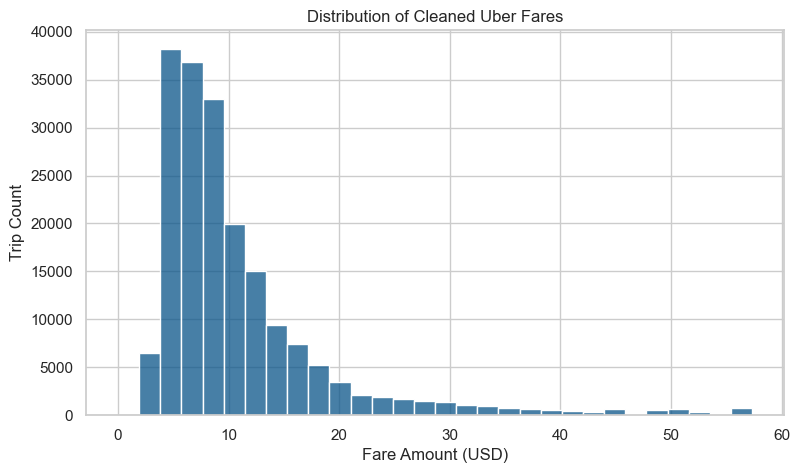

In [7]:
plt.figure(figsize=(9, 5))
sns.histplot(uber_clean["fare_amount"], bins=30, color="#095489")
plt.title("Distribution of Cleaned Uber Fares")
plt.xlabel("Fare Amount (USD)")
plt.ylabel("Trip Count")
plt.show()

Fares are right-skewed. The median fare is $8.50, and 95% of cleaned trips stay below $28.10. 

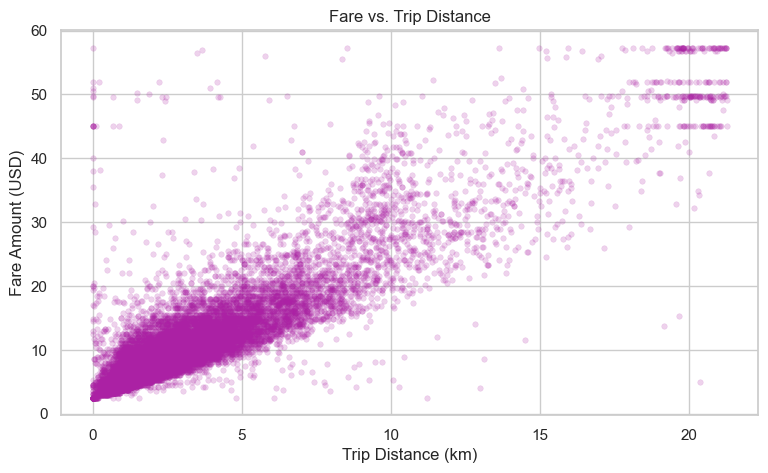

Fare–distance correlation: 0.89


In [8]:
scatter_sample = uber_clean.sample(
    n=min(20000, len(uber_clean)),
    random_state=RANDOM_STATE
)

plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=scatter_sample,
    x="trip_distance_km",
    y="fare_amount",
    alpha=0.2,
    s=16,
    color="#ab21a4",
    edgecolor=None,
)

plt.title("Fare vs. Trip Distance")
plt.xlabel("Trip Distance (km)")
plt.ylabel("Fare Amount (USD)")
plt.show()

distance_corr = uber_clean["trip_distance_km"].corr(uber_clean["fare_amount"])
print(f"Fare–distance correlation: {distance_corr:.2f}")

Distance is the dominant pricing signal in the Kaggle data. The fare-distance correlation is 0.89, which is strong for observational trip data. 

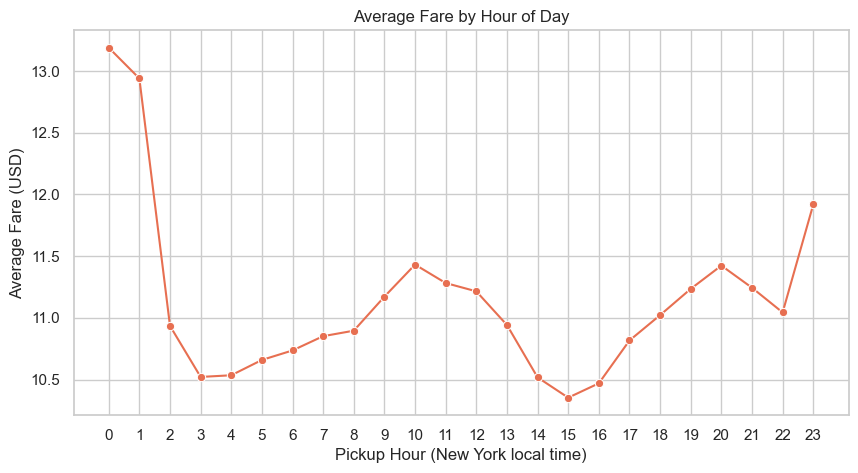

In [9]:
uber_clean["hour"] = uber_clean["pickup_datetime_local"].dt.hour
hourly_fare = uber_clean.groupby("hour")["fare_amount"].mean()

plt.figure(figsize=(10, 5))
sns.lineplot(x=hourly_fare.index, y=hourly_fare.values, marker="o", color="#e76f51")
plt.title("Average Fare by Hour of Day")
plt.xlabel("Pickup Hour (New York local time)")
plt.ylabel("Average Fare (USD)")
plt.xticks(range(0, 24))
plt.show()

peak_hour = int(hourly_fare.idxmax())
low_hour = int(hourly_fare.idxmin())

Average fares peak around 00:00 and are lowest around 15:00. The hourly pattern exists, but the gap across hours is still smaller than the effect of trip distance.

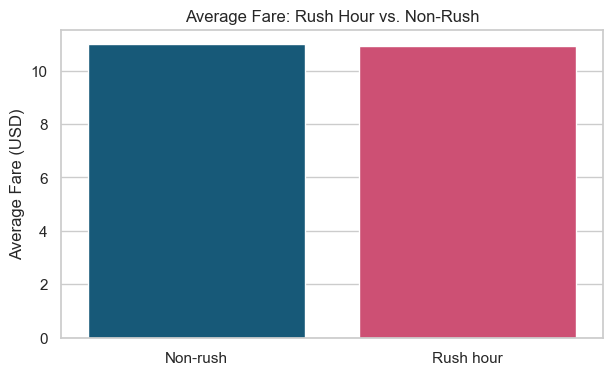

In [10]:
uber_clean["rush_hour"] = uber_clean["hour"].isin([7, 8, 9, 16, 17, 18, 19]).astype(int)
rush_summary = (
    uber_clean.groupby("rush_hour")["fare_amount"]
    .mean()
    .rename(index={0: "Non-rush", 1: "Rush hour"})
    .reset_index()
)

plt.figure(figsize=(7, 4))
sns.barplot(data=rush_summary, x="rush_hour", y="fare_amount", palette=["#075F88", "#e23b6b"])
plt.title("Average Fare: Rush Hour vs. Non-Rush")
plt.xlabel("")
plt.ylabel("Average Fare (USD)")
plt.show()

rush_diff = (
    uber_clean.loc[uber_clean["rush_hour"] == 1, "fare_amount"].mean()
    - uber_clean.loc[uber_clean["rush_hour"] == 0, "fare_amount"].mean()
)


Rush-hour fares differ by -0.07 dollars from non-rush periods on average. That reinforces the idea that timing matters, but not nearly as much as trip distance.

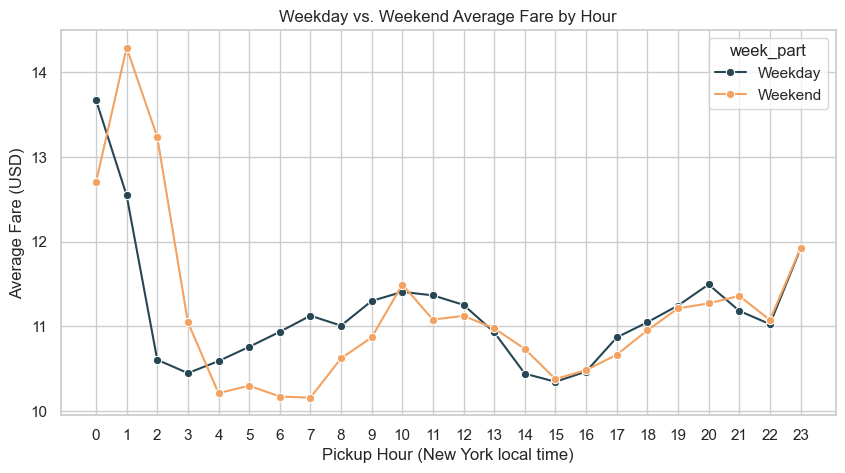

In [11]:
uber_clean["day_of_week"] = uber_clean["pickup_datetime_local"].dt.dayofweek
uber_clean["is_weekend"] = uber_clean["day_of_week"].isin([5, 6]).astype(int)
uber_clean["week_part"] = np.where(uber_clean["is_weekend"] == 1, "Weekend", "Weekday")

weekend_hourly = (
    uber_clean.groupby(["hour", "week_part"])["fare_amount"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=weekend_hourly,
    x="hour",
    y="fare_amount",
    hue="week_part",
    marker="o",
    palette=["#264653", "#f4a261"],
)
plt.title("Weekday vs. Weekend Average Fare by Hour")
plt.xlabel("Pickup Hour (New York local time)")
plt.ylabel("Average Fare (USD)")
plt.xticks(range(0, 24))
plt.show()

weekend_mean = uber_clean.loc[uber_clean["is_weekend"] == 1, "fare_amount"].mean()
weekday_mean = uber_clean.loc[uber_clean["is_weekend"] == 0, "fare_amount"].mean()
diff = weekend_mean - weekday_mean

Weekend fares differ from weekday fares by -0.03 dollars on average. That suggests calendar effects are present, but they are secondary compared with distance.

## 6. Feature Engineering (Core Section)

To build a strong model, I need features that capture both **where** a trip happens and **when** it happens.

**Temporal features**

- `hour`: captures intraday pricing rhythm.
- `day_of_week`: separates weekday and weekend behavior.
- `is_weekend`: creates a simpler calendar flag for business interpretation.
- `rush_hour`: captures commuting windows when demand and congestion may differ.

**Spatial features**

- `trip_distance_km`: Haversine distance between pickup and dropoff coordinates.
- Pickup and dropoff coordinates: preserve location context beyond pure distance.

**Advanced features**

- `distance_x_rush_hour`: lets the model test whether longer rides behave differently in commuting windows.
- `distance_x_weekend`: lets the model test whether distance has a different effect on weekends.
- `trip_duration`: not available in the Kaggle training dataset because there is no dropoff timestamp, so I do not include it in the modeling step.

In [12]:
uber_features = uber_clean.copy()

uber_features["rush_hour"] = uber_features["hour"].isin([7, 8, 9, 16, 17, 18, 19]).astype(int)
uber_features["distance_x_rush_hour"] = (
    uber_features["trip_distance_km"] * uber_features["rush_hour"]
)
uber_features["distance_x_weekend"] = (
    uber_features["trip_distance_km"] * uber_features["is_weekend"]
)

engineered_feature_columns = [
    "trip_distance_km",
    "pickup_longitude",
    "pickup_latitude",
    "dropoff_longitude",
    "dropoff_latitude",
    "passenger_count",
    "hour",
    "day_of_week",
    "is_weekend",
    "rush_hour",
    "distance_x_rush_hour",
    "distance_x_weekend",
]

The engineered dataset now combines spatial, geographic, and temporal signals in a format ready for machine learning models.

## 7. Modeling

In this step, I split the Kaggle dataset into training and test sets and train three comparable models:

1. **Linear Regression** as a transparent baseline.
2. **Random Forest** to capture nonlinear relationships and interactions.
3. **XGBoost** as a stronger gradient-boosted tree benchmark.

To keep the notebook runnable on a typical laptop, I use a reproducible sample of the cleaned Kaggle data for modeling. I do not use the validation dataset during training.

In [13]:
target = "fare_amount"

feature_columns = [
    "trip_distance_km",   
    "pickup_longitude",
    "pickup_latitude",
    "dropoff_longitude",
    "dropoff_latitude",
    "passenger_count",
    "hour",
    "rush_hour",
]

model_df = uber_features[feature_columns + [target]].copy()

model_sample_n = min(40000, len(model_df))
model_df = model_df.sample(n=model_sample_n, random_state=RANDOM_STATE)

X = model_df[feature_columns]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)


models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        max_depth=12,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "XGBoost": XGBRegressor(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
}

print(f"Modeling sample size: {len(model_df):,}")
print(f"Train size: {len(X_train):,}")
print(f"Test size: {len(X_test):,}")

Modeling sample size: 40,000
Train size: 32,000
Test size: 8,000


## 8. Evaluation

The primary metric is **MAE** because it is easy to interpret in dollars. I also include **RMSE** to show whether a model makes some larger misses.

Lower values are better for both metrics.

,Model,MAE,RMSE
0,XGBoost,1.964,3.352
1,Random Forest,1.989,3.390
2,Linear Regression,2.188,3.691


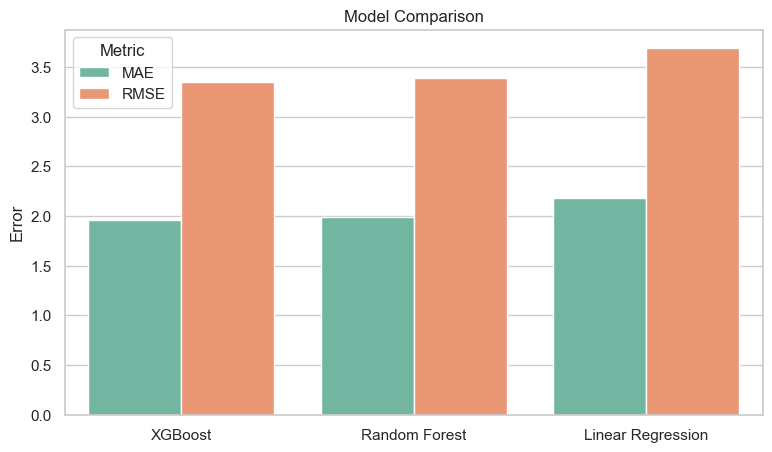

In [14]:
fitted_models = {}
results = []

for model_name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    fitted_models[model_name] = model
    results.append(
        {
            "Model": model_name,
            "MAE": mean_absolute_error(y_test, predictions),
            "RMSE": rmse(y_test, predictions),
        }
    )

results_df = pd.DataFrame(results).sort_values("MAE").reset_index(drop=True)
display(results_df.round(3))

results_long = results_df.melt(id_vars="Model", var_name="Metric", value_name="Value")
plt.figure(figsize=(9, 5))
sns.barplot(data=results_long, x="Model", y="Value", hue="Metric", palette="Set2")
plt.title("Model Comparison")
plt.ylabel("Error")
plt.xlabel("")
plt.show()

best_model_name = results_df.loc[0, "Model"]
best_mae = results_df.loc[0, "MAE"]
baseline_mae = results_df.loc[results_df["Model"] == "Linear Regression", "MAE"].iloc[0]

XGBoost achieved the lowest test MAE at $1.96. That is an improvement of $0.22 over the linear baseline. 

## 9. Model Interpretation

Prediction accuracy matters, but this project also aims to explain what drives fares.

To do this, I analyze feature importance from the tree-based models, since they capture nonlinear relationships more effectively than the linear baseline.

,Feature,Random Forest,XGBoost,Average Importance
0,trip_distance_km,0.8858,0.7258,0.8058
1,pickup_longitude,0.0248,0.0881,0.0565
2,dropoff_longitude,0.0313,0.0724,0.0518
3,dropoff_latitude,0.0239,0.0357,0.0298
4,pickup_latitude,0.0168,0.0298,0.0233
5,hour,0.0132,0.0174,0.0153
6,rush_hour,0.0016,0.0197,0.0107
7,passenger_count,0.0026,0.0110,0.0068


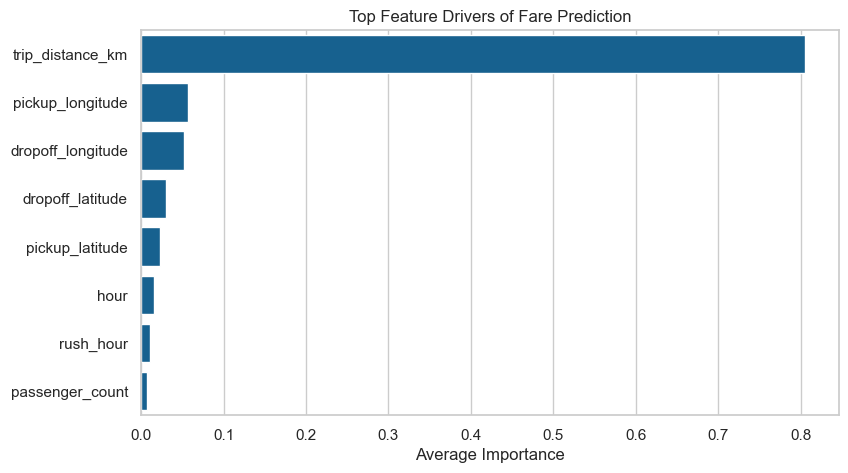

In [15]:
rf_model = models["Random Forest"]
xgb_model = models["XGBoost"]

importance_df = pd.DataFrame({
    "Feature": feature_columns,
    "Random Forest": rf_model.feature_importances_,
    "XGBoost": xgb_model.feature_importances_,
})

importance_df["Average Importance"] = importance_df[["Random Forest", "XGBoost"]].mean(axis=1)

importance_df = (
    importance_df
    .sort_values("Average Importance", ascending=False)
    .reset_index(drop=True)
)

display(importance_df.round(4))

plt.figure(figsize=(9, 5))
sns.barplot(
    data=importance_df.head(10),
    x="Average Importance",
    y="Feature",
    color="#0366a3",
)

plt.title("Top Feature Drivers of Fare Prediction")
plt.xlabel("Average Importance")
plt.ylabel("")
plt.show()

I also tested a richer feature set including additional temporal and interaction variables. However, these features did not materially improve model performance or interpretation, reinforcing that trip distance is the dominant driver. 

## 10. Cross-Dataset Validation (Differential Section)

The NYC Taxi dataset is used **only** to validate patterns, not to train any models.

I recreate comparable descriptive analyses, including:

- fare vs. distance
- hourly fare patterns
- weekday vs. weekend behavior

This helps confirm whether the core relationships identified in the Kaggle dataset also hold in a larger, real-world dataset.

In [16]:
nyc_clean = nyc_raw.copy()

nyc_clean = nyc_clean.dropna(
    subset=["tpep_pickup_datetime", "tpep_dropoff_datetime", "trip_distance", "fare_amount"]
)

nyc_clean = nyc_clean[
    (nyc_clean["fare_amount"] > 0) &
    (nyc_clean["trip_distance"] > 0)
]

valid_duration = (
    (nyc_clean["tpep_dropoff_datetime"] - nyc_clean["tpep_pickup_datetime"])
    .dt.total_seconds() >= 0
)

nyc_clean = nyc_clean[valid_duration]

fare_cap = nyc_clean["fare_amount"].quantile(0.995)
distance_cap = nyc_clean["trip_distance"].quantile(0.995)

nyc_clean = nyc_clean[
    (nyc_clean["fare_amount"] <= fare_cap) &
    (nyc_clean["trip_distance"] <= distance_cap)
]

nyc_clean["hour"] = nyc_clean["tpep_pickup_datetime"].dt.hour
nyc_clean["day_of_week"] = nyc_clean["tpep_pickup_datetime"].dt.dayofweek
nyc_clean["is_weekend"] = nyc_clean["day_of_week"].isin([5, 6]).astype(int)
nyc_clean["rush_hour"] = nyc_clean["hour"].isin([8, 9, 17, 18]).astype(int)

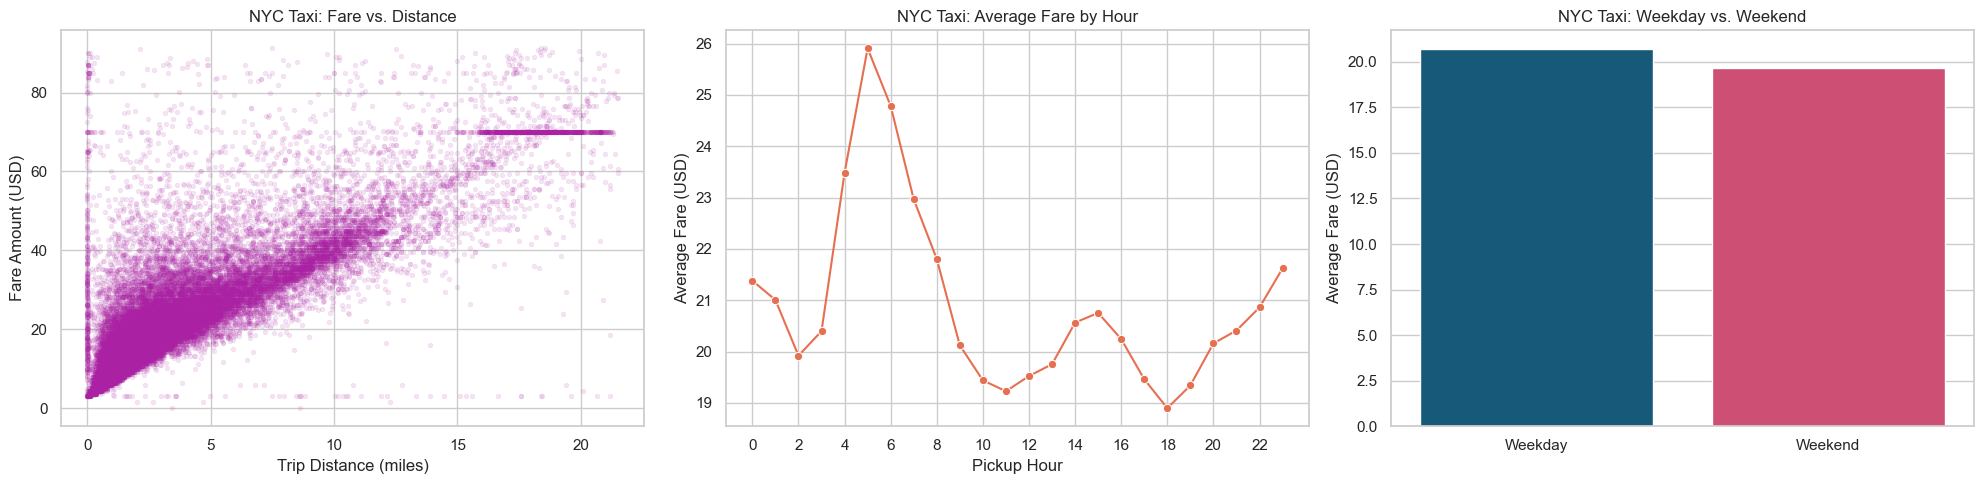

,Pattern,Kaggle Uber,NYC Taxi
0,Fare-distance correlation,0.888,0.862
1,Average weekday fare,10.960,20.700
2,Average weekend fare,10.930,19.650
3,Peak average-fare hour,0.000,5.000


In [17]:
nyc_scatter_sample = nyc_clean.sample(n=min(50000, len(nyc_clean)), random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.scatterplot(
    data=nyc_scatter_sample,
    x="trip_distance",
    y="fare_amount",
    alpha=0.12,
    s=12,
    color="#ab21a4",
    edgecolor=None,
    ax=axes[0],
)
axes[0].set_title("NYC Taxi: Fare vs. Distance")
axes[0].set_xlabel("Trip Distance (miles)")
axes[0].set_ylabel("Fare Amount (USD)")

nyc_hourly_fare = nyc_clean.groupby("hour")["fare_amount"].mean()
sns.lineplot(
    x=nyc_hourly_fare.index,
    y=nyc_hourly_fare.values,
    marker="o",
    color="#e76f51",
    ax=axes[1],
)
axes[1].set_title("NYC Taxi: Average Fare by Hour")
axes[1].set_xlabel("Pickup Hour")
axes[1].set_ylabel("Average Fare (USD)")
axes[1].set_xticks(range(0, 24, 2))

nyc_weekpart = (
    nyc_clean.assign(week_part=np.where(nyc_clean["is_weekend"] == 1, "Weekend", "Weekday"))
    .groupby("week_part")["fare_amount"]
    .mean()
    .reset_index()
)
sns.barplot(
    data=nyc_weekpart,
    x="week_part",
    y="fare_amount",
    palette=["#075F88", "#e23b6b"],
    ax=axes[2],
)
axes[2].set_title("NYC Taxi: Weekday vs. Weekend")
axes[2].set_xlabel("")
axes[2].set_ylabel("Average Fare (USD)")

plt.tight_layout()
plt.show()

uber_distance_corr = uber_clean["trip_distance_km"].corr(uber_clean["fare_amount"])
nyc_distance_corr = nyc_clean["trip_distance"].corr(nyc_clean["fare_amount"])

comparison_df = pd.DataFrame(
    [
        {
            "Pattern": "Fare-distance correlation",
            "Kaggle Uber": round(uber_distance_corr, 3),
            "NYC Taxi": round(nyc_distance_corr, 3),
        },
        {
            "Pattern": "Average weekday fare",
            "Kaggle Uber": round(
                uber_clean.loc[uber_clean["is_weekend"] == 0, "fare_amount"].mean(), 2
            ),
            "NYC Taxi": round(
                nyc_clean.loc[nyc_clean["is_weekend"] == 0, "fare_amount"].mean(), 2
            ),
        },
        {
            "Pattern": "Average weekend fare",
            "Kaggle Uber": round(
                uber_clean.loc[uber_clean["is_weekend"] == 1, "fare_amount"].mean(), 2
            ),
            "NYC Taxi": round(
                nyc_clean.loc[nyc_clean["is_weekend"] == 1, "fare_amount"].mean(), 2
            ),
        },
        {
            "Pattern": "Peak average-fare hour",
            "Kaggle Uber": int(uber_clean.groupby("hour")["fare_amount"].mean().idxmax()),
            "NYC Taxi": int(nyc_hourly_fare.idxmax()),
        },
    ]
)

display(comparison_df)

The broad spatial pattern is consistent across both datasets because fares rise strongly with trip distance in each one. Temporal effects also exist in both datasets, but the exact hourly peaks differ, which suggests time modifies pricing rather than fully driving it.

## 11. Final Insights

This section translates the analysis into business language.

1. **What drives higher fares?**

   Longer trips are the main driver, with *trip_distance_km* dominating the tree-based importance rankings. Pickup and dropoff coordinates add extra local context beyond raw distance.

2. **When are rides more expensive?**

   In the Kaggle training data, average fares are highest around 00:00 local time. Weekend fares differ from weekday fares by -0.03 dollars on average, so timing matters, but not as much as trip geometry.

3. **What patterns are consistent across datasets?**

   The strongest shared pattern is that longer trips cost more. Both datasets also show temporal variation, but those time-based effects are smaller and less stable than the spatial distance effect.

## 12. Limitations

I aim to be transparent about what this analysis cannot capture:

- There is no surge pricing or real-time supply–demand signal in the data.
- No weather, public events, traffic state, or route choice information is included.
- The Kaggle Uber dataset is a proxy for platform pricing, not the actual Uber pricing engine.
- The NYC Taxi validation file uses taxi zone IDs rather than raw coordinates, so spatial validation is broad rather than exact.
- The modeling section uses a reproducible sample of the cleaned Kaggle data to keep notebook runtime practical on a standard laptop.

## 13. Conclusion

This project combines fare prediction with interpretable spatial-temporal reasoning. The evaluation stage identifies the best-performing model with MAE and RMSE, while the interpretation stage shows that distance is the main driver and time effects mostly fine-tune the estimate.

The NYC Taxi validation dataset strengthens confidence in the main conclusion: the broad distance-fare relationship transfers across datasets, while temporal effects are real but comparatively weaker and less stable.

**Overall, the focus of this project is not just on prediction accuracy, but on understanding the patterns that drive pricing behavior.**